In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os

drive_dataset_path = "/content/drive/MyDrive/Dataset/Dataset"
local_dataset_path = "/content/Dataset"

if not os.path.exists(local_dataset_path):
    shutil.copytree(drive_dataset_path, local_dataset_path)

print("✅ Dataset copied to local path")

✅ Dataset copied to local path


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = datasets.ImageFolder(local_dataset_path, transform=train_transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

val_dataset.dataset.transform = val_test_transform
test_dataset.dataset.transform = val_test_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4426
Val: 948
Test: 949


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 5)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 103MB/s]


In [ ]:
EPOCHS = 20
best_val_acc = 0

print("🚀 Starting DenseNet Training")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"✅ Epoch {epoch+1} Completed | Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_densenet121.pth")
        print("💾 Best Model Saved")

print("🔥 Training Completed")

🚀 Starting DenseNet Training
Epoch [1/20] Batch [0/139] Loss: 0.0673
Epoch [1/20] Batch [20/139] Loss: 0.0695
Epoch [1/20] Batch [40/139] Loss: 0.0661
Epoch [1/20] Batch [60/139] Loss: 0.0338
Epoch [1/20] Batch [80/139] Loss: 0.0355
Epoch [1/20] Batch [100/139] Loss: 0.1756
Epoch [1/20] Batch [120/139] Loss: 0.0346
✅ Epoch 1 Completed | Val Accuracy: 0.9494
💾 Best Model Saved
Epoch [2/20] Batch [0/139] Loss: 0.0080
Epoch [2/20] Batch [20/139] Loss: 0.0174
Epoch [2/20] Batch [40/139] Loss: 0.0333
Epoch [2/20] Batch [60/139] Loss: 0.0128
Epoch [2/20] Batch [80/139] Loss: 0.0324
Epoch [2/20] Batch [100/139] Loss: 0.0354
Epoch [2/20] Batch [120/139] Loss: 0.0101
✅ Epoch 2 Completed | Val Accuracy: 0.9662
💾 Best Model Saved
Epoch [3/20] Batch [0/139] Loss: 0.0167
Epoch [3/20] Batch [20/139] Loss: 0.0189
Epoch [3/20] Batch [40/139] Loss: 0.0130
Epoch [3/20] Batch [60/139] Loss: 0.0451
Epoch [3/20] Batch [80/139] Loss: 0.0337
Epoch [3/20] Batch [100/139] Loss: 0.0106
Epoch [3/20] Batch [120/1

KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load("/content/drive/MyDrive/densenet_checkpoint.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]
best_val_acc = checkpoint["best_val_acc"]

print("Resuming from epoch:", start_epoch)

Resuming from epoch: 8


In [ ]:
EPOCHS = 20

for epoch in range(start_epoch, EPOCHS):

    model.train()
    running_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 20 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    # Validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"✅ Epoch {epoch+1} Completed | Val Accuracy: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_densenet121.pth")
        print("💾 Best Model Saved")

Epoch [9/20] Batch [0/139] Loss: 0.1886
Epoch [9/20] Batch [20/139] Loss: 0.0676
Epoch [9/20] Batch [40/139] Loss: 0.0126
Epoch [9/20] Batch [60/139] Loss: 0.1325
Epoch [9/20] Batch [80/139] Loss: 0.0056
Epoch [9/20] Batch [100/139] Loss: 0.0795
Epoch [9/20] Batch [120/139] Loss: 0.0437
✅ Epoch 9 Completed | Val Accuracy: 0.9842
💾 Best Model Saved
Epoch [10/20] Batch [0/139] Loss: 0.0068
Epoch [10/20] Batch [20/139] Loss: 0.0092
Epoch [10/20] Batch [40/139] Loss: 0.0017
Epoch [10/20] Batch [60/139] Loss: 0.0025
Epoch [10/20] Batch [80/139] Loss: 0.0283
Epoch [10/20] Batch [100/139] Loss: 0.0220
Epoch [10/20] Batch [120/139] Loss: 0.0129
✅ Epoch 10 Completed | Val Accuracy: 0.9926
💾 Best Model Saved
Epoch [11/20] Batch [0/139] Loss: 0.0077
Epoch [11/20] Batch [20/139] Loss: 0.0009
Epoch [11/20] Batch [40/139] Loss: 0.0009
Epoch [11/20] Batch [60/139] Loss: 0.0007
Epoch [11/20] Batch [80/139] Loss: 0.0019
Epoch [11/20] Batch [100/139] Loss: 0.0007
Epoch [11/20] Batch [120/139] Loss: 0.02

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/best_densenet121_final.pth")
print("✅ Best model saved")

✅ Best model saved


In [ ]:
torch.save({
    "epoch": 12,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_val_acc": best_val_acc
}, "/content/drive/MyDrive/densenet_checkpoint_final.pth")

print("✅ Checkpoint saved at epoch 12")

✅ Checkpoint saved at epoch 12


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import shutil
import os

drive_dataset_path = "/content/drive/MyDrive/Dataset/Dataset"
local_dataset_path = "/content/Dataset"

if not os.path.exists(local_dataset_path):
    shutil.copytree(drive_dataset_path, local_dataset_path)

print("✅ Dataset copied locally")

✅ Dataset copied locally


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = datasets.ImageFolder(local_dataset_path, transform=val_test_transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4426
Val: 948
Test: 949


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, 5)

model.load_state_dict(torch.load(
    "/content/drive/MyDrive/best_densenet121.pth",
    map_location=device
))

model = model.to(device)
model.eval()

print("✅ DenseNet121 loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ DenseNet121 loaded successfully


In [ ]:
!pip install grad-cam

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

target_layer = model.features[-1]

gradcam_pp = GradCAMPlusPlus(model=model, target_layers=[target_layer])
scorecam = ScoreCAM(model=model, target_layers=[target_layer])

100%|██████████| 64/64 [02:50<00:00,  2.66s/it]


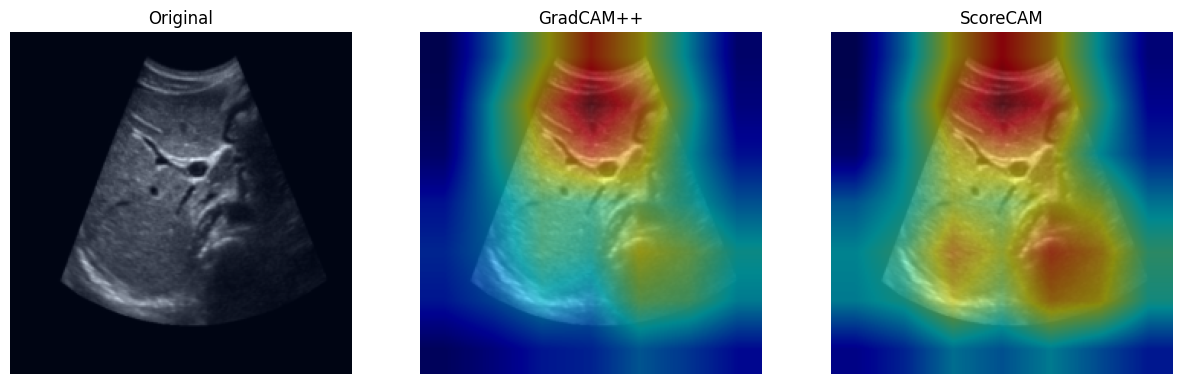

In [ ]:
images, labels = next(iter(test_loader))

input_tensor = images[0].unsqueeze(0).to(device)

cam_pp = gradcam_pp(input_tensor=input_tensor)[0]
cam_sc = scorecam(input_tensor=input_tensor)[0]

img = images[0].permute(1,2,0).numpy()
img = (img - img.min()) / (img.max() - img.min())

cam_pp_image = show_cam_on_image(img, cam_pp, use_rgb=True)
cam_sc_image = show_cam_on_image(img, cam_sc, use_rgb=True)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("GradCAM++")
plt.imshow(cam_pp_image)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("ScoreCAM")
plt.imshow(cam_sc_image)
plt.axis("off")

plt.show()

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus, ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import torch

target_layer = model.features[-1]

gradcam_pp = GradCAMPlusPlus(model=model, target_layers=[target_layer])
scorecam = ScoreCAM(model=model, target_layers=[target_layer])

class_names = full_dataset.classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

100%|██████████| 64/64 [03:06<00:00,  2.91s/it]


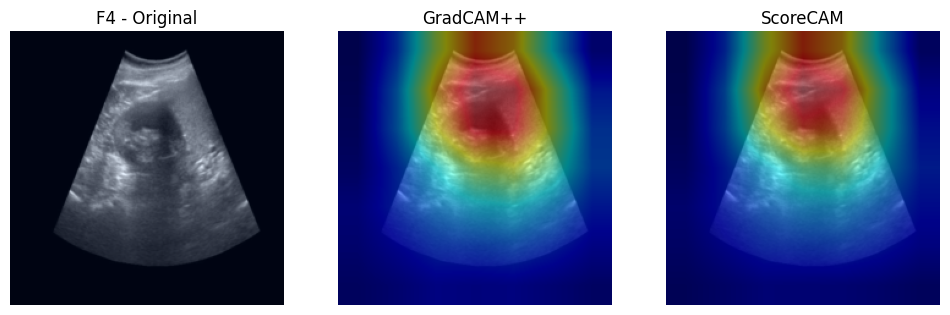

100%|██████████| 64/64 [02:47<00:00,  2.62s/it]


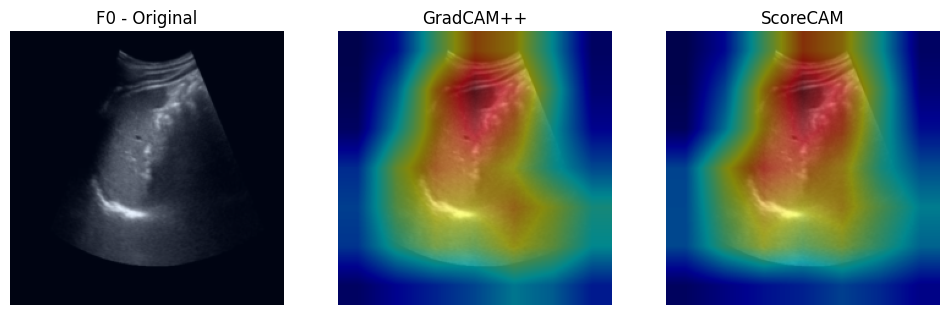

100%|██████████| 64/64 [03:10<00:00,  2.97s/it]


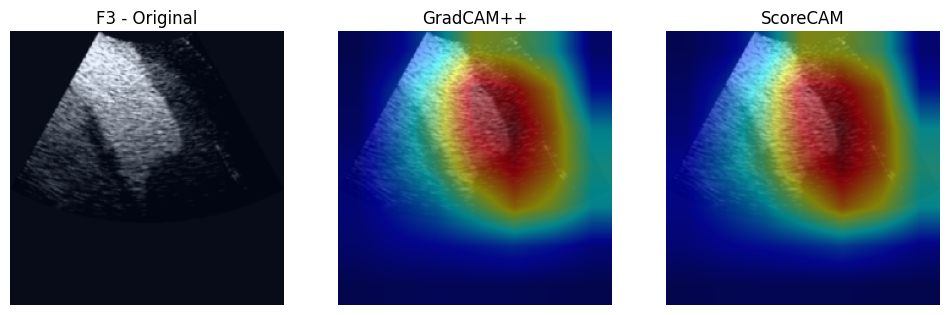

100%|██████████| 64/64 [03:10<00:00,  2.98s/it]


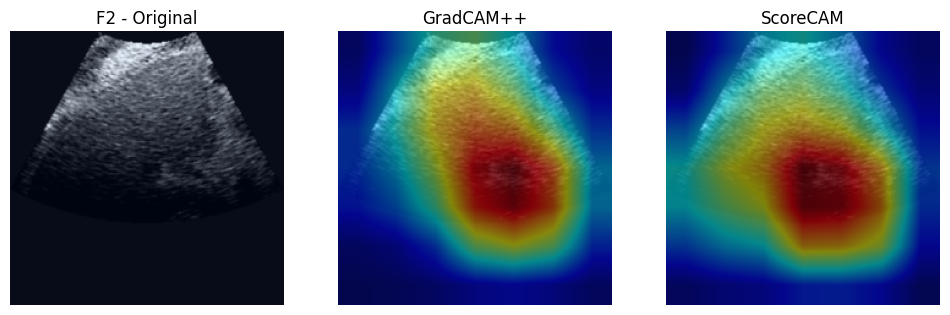

100%|██████████| 64/64 [03:12<00:00,  3.00s/it]


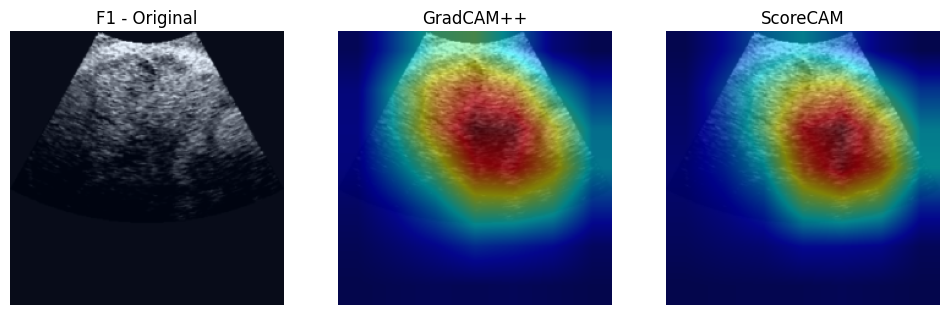

✅ Generated XAI for all stages


In [ ]:
found_classes = set()

model.eval()

for images, labels in test_loader:
    images = images.to(device)
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

    for i in range(len(images)):
        true_label = labels[i].item()
        pred_label = preds[i].item()

        # Only use correctly predicted images
        if true_label == pred_label and true_label not in found_classes:

            input_tensor = images[i].unsqueeze(0)

            # Generate CAMs
            cam_pp = gradcam_pp(input_tensor=input_tensor)[0]
            cam_sc = scorecam(input_tensor=input_tensor)[0]

            # Convert image properly
            img = images[i].cpu().permute(1,2,0).numpy()
            img = (img - img.min()) / (img.max() - img.min())

            cam_pp_image = show_cam_on_image(img, cam_pp, use_rgb=True)
            cam_sc_image = show_cam_on_image(img, cam_sc, use_rgb=True)

            # Plot
            plt.figure(figsize=(12,4))

            plt.subplot(1,3,1)
            plt.title(f"{class_names[true_label]} - Original")
            plt.imshow(img)
            plt.axis("off")

            plt.subplot(1,3,2)
            plt.title("GradCAM++")
            plt.imshow(cam_pp_image)
            plt.axis("off")

            plt.subplot(1,3,3)
            plt.title("ScoreCAM")
            plt.imshow(cam_sc_image)
            plt.axis("off")

            plt.show()

            found_classes.add(true_label)

    if len(found_classes) == len(class_names):
        break

print("✅ Generated XAI for all stages")

In [ ]:
import pandas as pd
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

sens_spec_data = []

for i, class_name in enumerate(full_dataset.classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    sens_spec_data.append([class_name, sensitivity, specificity])

sens_spec_df = pd.DataFrame(
    sens_spec_data,
    columns=["Fibrosis Stage (METAVIR)", "Sensitivity (Recall)", "Specificity"]
)

print("===== Sensitivity & Specificity Table =====")
print(sens_spec_df)

===== Sensitivity & Specificity Table =====
  Fibrosis Stage (METAVIR)  Sensitivity (Recall)  Specificity
0                       F0                   1.0          1.0
1                       F1                   1.0          1.0
2                       F2                   1.0          1.0
3                       F3                   1.0          1.0
4                       F4                   1.0          1.0


In [ ]:
from sklearn.metrics import classification_report

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=full_dataset.classes,
    output_dict=True
)

rows = []
for class_name in full_dataset.classes:
    rows.append([
        class_name,
        report_dict[class_name]["precision"],
        report_dict[class_name]["recall"],
        report_dict[class_name]["f1-score"],
        report_dict[class_name]["support"]
    ])

metrics_df = pd.DataFrame(
    rows,
    columns=["Fibrosis Stage (METAVIR)", "Precision", "Recall", "F1-Score", "Support"]
)

print("\n===== Precision / Recall / F1 / Support Table =====")
print(metrics_df)


===== Precision / Recall / F1 / Support Table =====
  Fibrosis Stage (METAVIR)  Precision  Recall  F1-Score  Support
0                       F0        1.0     1.0       1.0    315.0
1                       F1        1.0     1.0       1.0    133.0
2                       F2        1.0     1.0       1.0    134.0
3                       F3        1.0     1.0       1.0    121.0
4                       F4        1.0     1.0       1.0    246.0


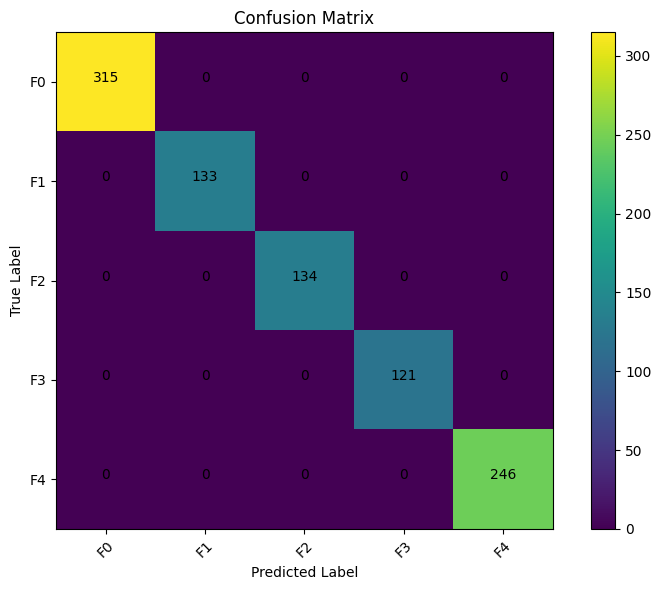

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(full_dataset.classes))
plt.xticks(tick_marks, full_dataset.classes, rotation=45)
plt.yticks(tick_marks, full_dataset.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

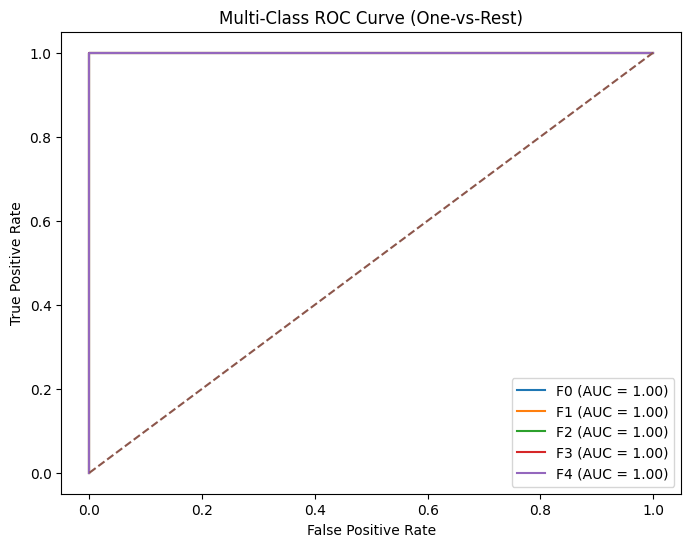

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels
y_true_bin = label_binarize(all_labels, classes=range(len(full_dataset.classes)))

plt.figure(figsize=(8,6))

for i in range(len(full_dataset.classes)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{full_dataset.classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import torch.nn.functional as F
import numpy as np

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [ ]:
accuracy = accuracy_score(all_labels, all_preds)

precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')
f1_macro = f1_score(all_labels, all_preds, average='macro')

precision_weighted = precision_score(all_labels, all_preds, average='weighted')
recall_weighted = recall_score(all_labels, all_preds, average='weighted')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("===== Overall Metrics =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"ROC-AUC (OvR): {roc_auc:.4f}")

===== Overall Metrics =====
Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1 Score (Macro): 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1 Score (Weighted): 1.0000
ROC-AUC (OvR): 1.0000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

dataset_path = "/content/drive/MyDrive/Dataset/Dataset"  # change if needed

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Dataset loaded successfully")

Dataset loaded successfully


In [ ]:
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, len(full_dataset.classes))
model = model.to(device)

checkpoint_path = "/content/drive/MyDrive/best_densenet121.pth"  # change if needed
checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint)
model.eval()

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("Evaluation completed")

Evaluation completed


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=None)
recall = recall_score(all_labels, all_preds, average=None)
f1 = f1_score(all_labels, all_preds, average=None)

print("Overall Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

Overall Accuracy: 0.9978925184404637

Classification Report:

              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       303
          F1       1.00      0.98      0.99       127
          F2       0.99      1.00      1.00       132
          F3       1.00      1.00      1.00       131
          F4       1.00      1.00      1.00       256

    accuracy                           1.00       949
   macro avg       1.00      1.00      1.00       949
weighted avg       1.00      1.00      1.00       949



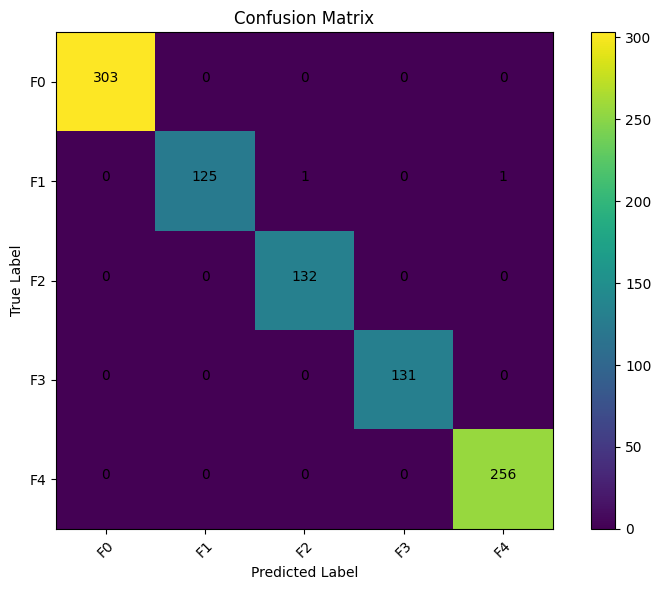

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(full_dataset.classes))
plt.xticks(tick_marks, full_dataset.classes, rotation=45)
plt.yticks(tick_marks, full_dataset.classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

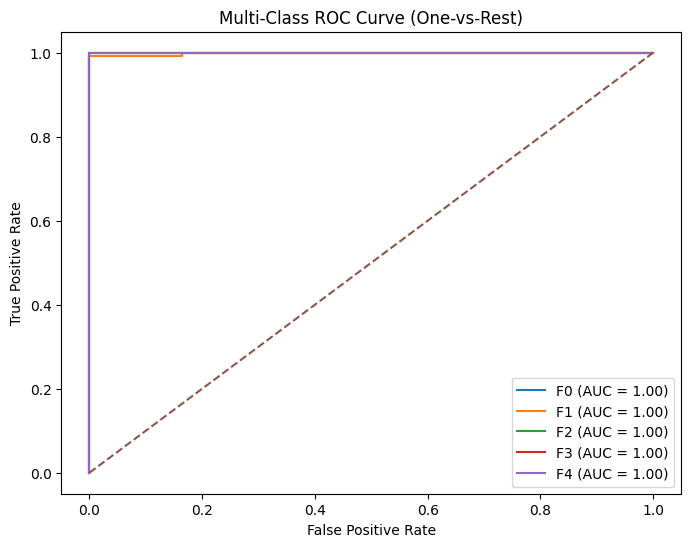

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(all_labels, classes=range(len(full_dataset.classes)))

plt.figure(figsize=(8,6))

for i in range(len(full_dataset.classes)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{full_dataset.classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split

dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

train_size = int(0.7 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

torch.save({
    "train_indices": train_dataset.indices,
    "val_indices": val_dataset.indices,
    "test_indices": test_dataset.indices
}, "/content/drive/MyDrive/split_indices.pth")

print("Split created and saved successfully.")

Split created and saved successfully.


In [ ]:
split = torch.load("/content/drive/MyDrive/split_indices.pth")

train_dataset = torch.utils.data.Subset(full_dataset, split["train_indices"])
val_dataset   = torch.utils.data.Subset(full_dataset, split["val_indices"])
test_dataset  = torch.utils.data.Subset(full_dataset, split["test_indices"])

print("Split loaded successfully.")

Split loaded successfully.


In [ ]:
split = torch.load("/content/drive/MyDrive/split_indices.pth")

train_dataset = torch.utils.data.Subset(full_dataset, split["train_indices"])
val_dataset   = torch.utils.data.Subset(full_dataset, split["val_indices"])
test_dataset  = torch.utils.data.Subset(full_dataset, split["test_indices"])

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Using original training split")

Using original training split


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['F0', 'F1', 'F2', 'F3', 'F4']
Total images: 6323


In [ ]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.densenet121(pretrained=False)

model.classifier = nn.Linear(model.classifier.in_features, 5)

# Load the full checkpoint dictionary
checkpoint = torch.load(
    "/content/drive/MyDrive/densenet_checkpoint.pth",
    map_location=device
)

# Extract only the model's state_dict
model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

In [ ]:
print("Classification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    target_names=full_dataset.classes
))

accuracy = accuracy_score(all_labels, all_preds)

print("Overall Accuracy:", accuracy)

Classification Report:

              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       303
          F1       0.94      0.98      0.96       127
          F2       0.97      0.91      0.94       132
          F3       0.98      0.96      0.97       131
          F4       0.98      1.00      0.99       256

    accuracy                           0.98       949
   macro avg       0.97      0.97      0.97       949
weighted avg       0.98      0.98      0.98       949

Overall Accuracy: 0.9799789251844047


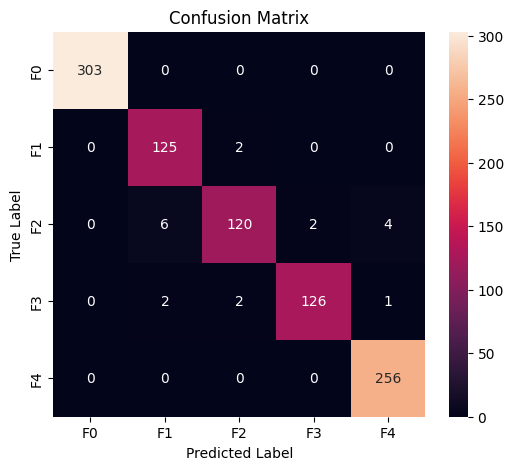

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("\nSensitivity and Specificity:\n")

for i in range(len(full_dataset.classes)):

    TP = cm[i,i]

    FN = cm[i,:].sum() - TP

    FP = cm[:,i].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN)

    specificity = TN / (TN + FP)

    print(full_dataset.classes[i])

    print("Sensitivity:", round(sensitivity,4))

    print("Specificity:", round(specificity,4))

    print()


Sensitivity and Specificity:

F0
Sensitivity: 1.0
Specificity: 1.0

F1
Sensitivity: 0.9843
Specificity: 0.9903

F2
Sensitivity: 0.9091
Specificity: 0.9951

F3
Sensitivity: 0.9618
Specificity: 0.9976

F4
Sensitivity: 1.0
Specificity: 0.9928



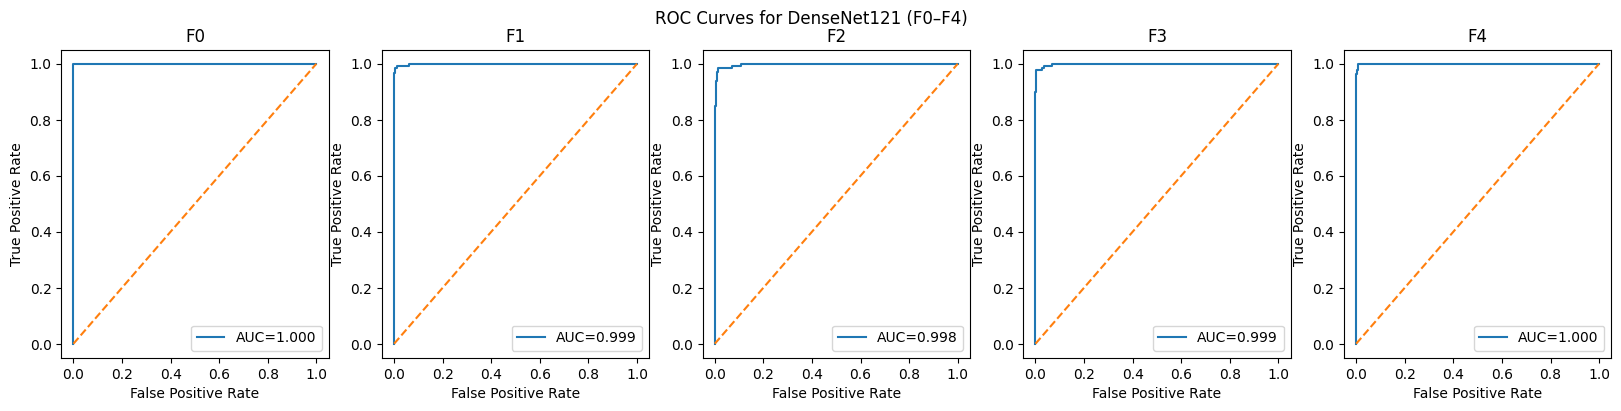

In [ ]:
all_probs = np.array(all_probs)

y_true_bin = label_binarize(all_labels, classes=[0,1,2,3,4])

fig, axes = plt.subplots(1,5, figsize=(20,4))

for i in range(5):

    fpr, tpr, _ = roc_curve(y_true_bin[:,i], all_probs[:,i])

    roc_auc = auc(fpr,tpr)

    axes[i].plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")

    axes[i].plot([0,1],[0,1],'--')

    axes[i].set_title(full_dataset.classes[i])

    axes[i].set_xlabel("False Positive Rate")

    axes[i].set_ylabel("True Positive Rate")

    axes[i].legend()

plt.suptitle("ROC Curves for DenseNet121 (F0–F4)")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

classes = full_dataset.classes

sensitivity = []
specificity = []

for i in range(len(classes)):

    TP = cm[i,i]

    FN = cm[i,:].sum() - TP

    FP = cm[:,i].sum() - TP

    TN = cm.sum() - (TP + FN + FP)

    sens = TP / (TP + FN)

    spec = TN / (TN + FP)

    sensitivity.append(round(sens,4))
    specificity.append(round(spec,4))


table1 = pd.DataFrame({
    "Fibrosis Stage (METAVIR)": classes,
    "Sensitivity (Recall)": sensitivity,
    "Specificity": specificity
})

print(table1)

  Fibrosis Stage (METAVIR)  Sensitivity (Recall)  Specificity
0                       F0                1.0000       1.0000
1                       F1                0.9843       0.9903
2                       F2                0.9091       0.9951
3                       F3                0.9618       0.9976
4                       F4                1.0000       0.9928


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    all_labels,
    all_preds
)

accuracy = accuracy_score(all_labels, all_preds)

table2 = pd.DataFrame({
    "Fibrosis Stage (METAVIR)": classes,
    "Precision": np.round(precision,4),
    "Recall": np.round(recall,4),
    "F1 Score": np.round(f1,4),
    "Support": support
})

print(table2)

print("\nAccuracy:", round(accuracy,4))

  Fibrosis Stage (METAVIR)  Precision  Recall  F1 Score  Support
0                       F0     1.0000  1.0000    1.0000      303
1                       F1     0.9398  0.9843    0.9615      127
2                       F2     0.9677  0.9091    0.9375      132
3                       F3     0.9844  0.9618    0.9730      131
4                       F4     0.9808  1.0000    0.9903      256

Accuracy: 0.98


In [ ]:
display(table1)
display(table2)

,Fibrosis Stage (METAVIR),Sensitivity (Recall),Specificity
0,F0,1.0000,1.0000
1,F1,0.9843,0.9903
2,F2,0.9091,0.9951
3,F3,0.9618,0.9976
4,F4,1.0000,0.9928


,Fibrosis Stage (METAVIR),Precision,Recall,F1 Score,Support
0,F0,1.0000,1.0000,1.0000,303
1,F1,0.9398,0.9843,0.9615,127
2,F2,0.9677,0.9091,0.9375,132
3,F3,0.9844,0.9618,0.9730,131
4,F4,0.9808,1.0000,0.9903,256


In [ ]:
import matplotlib.pyplot as plt

def save_table(df, filename):

    fig, ax = plt.subplots()

    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=df.values,
                     colLabels=df.columns,
                     loc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)

    plt.savefig(filename, bbox_inches='tight')
    plt.close()

save_table(table1,"sensitivity_specificity.png")
save_table(table2,"classification_metrics.png")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset copied to local storage!
Data Loaded!


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model Loaded!
Prediction Done!


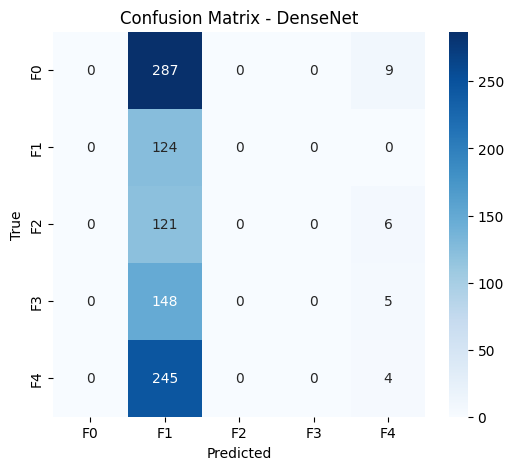

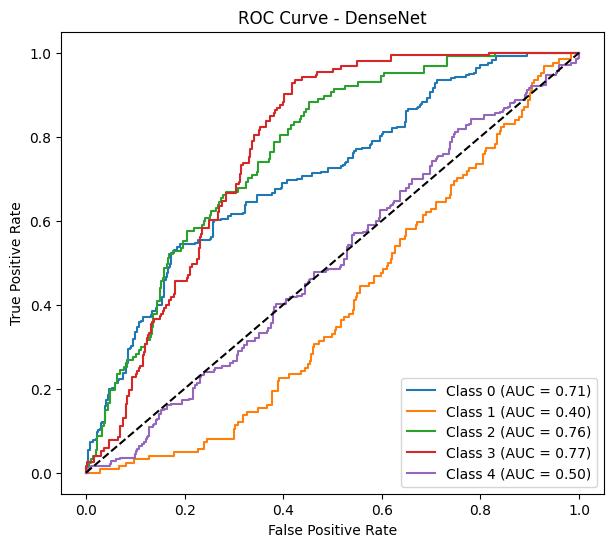

In [2]:
# ================================
# 1. MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive')

# ================================
# 2. COPY DATASET TO LOCAL (FASTER)
# ================================
import shutil

# 👉 Change this to your dataset path in Drive
drive_dataset_path = "/content/drive/MyDrive/Dataset/Dataset"

# Local path
local_dataset_path = "/content/dataset"

# Copy
shutil.copytree(drive_dataset_path, local_dataset_path, dirs_exist_ok=True)

print("Dataset copied to local storage!")

# ================================
# 3. LOAD DATASET
# ================================
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(local_dataset_path, transform=transform)

# Split (70-15-15)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Data Loaded!")

# ================================
# 4. LOAD MODEL (DENSENET EXAMPLE)
# ================================
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.densenet121(pretrained=False)
model.classifier = nn.Linear(model.classifier.in_features, 5)

# 👉 Change path
model_path = "/content/drive/MyDrive/best_densenet_fast.pth"

model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

print("Model Loaded!")

# ================================
# 5. TEST PREDICTIONS
# ================================
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Prediction Done!")

# ================================
# 6. CONFUSION MATRIX
# ================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['F0','F1','F2','F3','F4'],
            yticklabels=['F0','F1','F2','F3','F4'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DenseNet")
plt.show()

# ================================
# 7. ROC CURVE (MULTI-CLASS)
# ================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_true = label_binarize(all_labels, classes=[0,1,2,3,4])
y_score = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        y_score.extend(probs.cpu().numpy())

y_score = np.array(y_score)

plt.figure(figsize=(7,6))

for i in range(5):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet")
plt.legend()
plt.show()